# 02 · Gas breakdown — CH₄ vs N₂O vs CO₂

**Question:** which *gas* drives the agrifood footprint? Matters for strategy: methane (CH₄) is short-lived, so cutting it buys fast climate wins, while CO₂ from land conversion is long-lived. A different lever per gas.

## Setup

In [1]:
import sys; sys.path.append('..')
import pandas as pd, matplotlib.pyplot as plt
from src import load, clean, footprint, viz

data = load.load_all()
emis, inten, land = data['emissions'], data['intensities'], data['landuse']
emis_c, _  = clean.split_countries_aggregates(emis)
inten_c, _ = clean.split_countries_aggregates(inten)
land_c, _  = clean.split_countries_aggregates(land)
YEAR = clean.pick_analysis_year(emis_c)
ELEM = clean.pick_co2eq_element(emis_c)
print('year', YEAR, '| element', ELEM)

year 2023 | element Emissions (CO2eq) (AR5)


## Gas split for the analysis year

CO2 (residual)    1.980878e+07
CH4               1.452697e+07
N2O               9.301287e+06
F-gases           1.365366e+06
dtype: float64


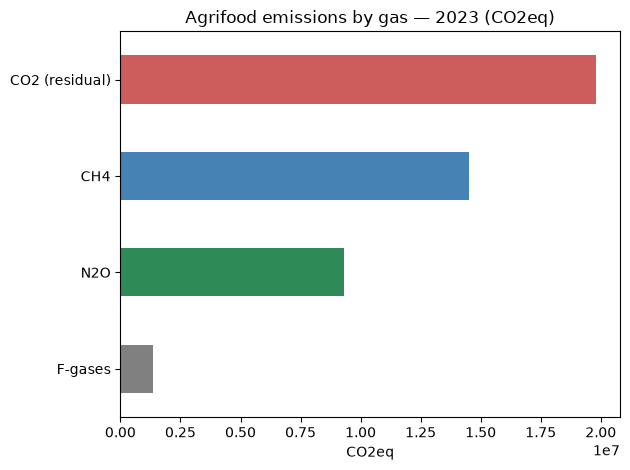

In [2]:
gases = footprint.gas_breakdown(emis_c, YEAR)
print(gases)
colors = {'CO2 (residual)': 'indianred', 'CH4': 'steelblue', 'N2O': 'seagreen', 'F-gases': 'grey'}
ordered = gases.sort_values()  # ascending so the largest bar plots at the top
ax = ordered.plot.barh(color=[colors.get(g, 'grey') for g in ordered.index])
ax.set_title(f'Agrifood emissions by gas — {YEAR} (CO2eq)')
ax.set_xlabel('CO2eq'); plt.tight_layout(); plt.show()

> **Read:** CH₄ heavy → livestock/rice levers (enteric, paddies). N₂O heavy → fertilizer/soils. CO₂ heavy → land-use change. The mix tells you which mitigation family matters most. *Note: CO2 is a residual (all-gas total minus named gases); confirm against FAOSTAT if you report it precisely.*

## Which sources carry the methane?

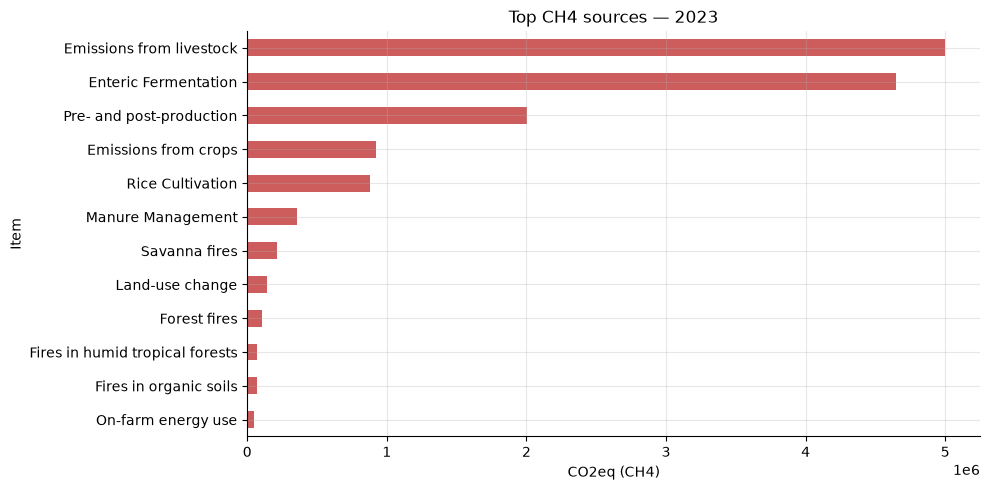

Item
Emissions from livestock    4.999024e+06
Enteric Fermentation        4.644648e+06
Pre- and post-production    2.005400e+06
Emissions from crops        9.232424e+05
Rice Cultivation            8.790394e+05
Manure Management           3.543766e+05
Savanna fires               2.168857e+05
Land-use change             1.417479e+05
Name: Value, dtype: float64

In [3]:
ch4 = 'Emissions (CO2eq) from CH4 (AR5)'
src_ch4 = footprint.rank_sources(emis_c, YEAR, ch4)
viz.barh_ranking(src_ch4, f'Top CH4 sources — {YEAR}', 'CO2eq (CH4)', color='indianred'); plt.show()
src_ch4.head(8)